# Denoise a single channel from the EDX

In [6]:
pip install humanfriendly

  Using cached humanfriendly-10.0-py2.py3-none-any.whl.metadata (9.2 kB)
Using cached humanfriendly-10.0-py2.py3-none-any.whl (86 kB)
Note: you may need to restart the kernel to use updated packages.


In [31]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import torch
from torch.utils.data import DataLoader
from model import UNet
from utils_noise import *
from bm3d import bm3d, BM3DStages
from bm4d import bm4d, BM4DStages
import pickle
import copy
import time
import humanfriendly
from skimage.restoration import estimate_sigma

device = torch.device("mps")
print(device)

%load_ext autoreload
%autoreload 2

mps
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data (the aligned and spectral-binned tile)

In [2]:
# Load aligned dataset
with open('../preprocessing_basic/results/preprocessed_edx/20251201_142554_tile_aligned.pkl', 'rb') as file:
    tile = pickle.load(file)

#### Load a reference (100 frame tile)

In [3]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# load and preprocess
edx, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=100, sum_frames=True, haadf_last_frame=False)
print(haadf.shape)

tile_ref = EM_EDX(haadf[0,:,:], edx, xray_energies)
tile_ref.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_ref.apply("binning", parameters={"dim": (2048, 2048, 250)})
#tile_ref.apply("MeanFilterEDX", parameters={"kernel_size": 3})

# check if same haadf
print(np.array_equal(tile.haadf,tile_ref.haadf))

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
(100, 2048, 2048)
True


#### Select a channel and denoise it

In [25]:
# global sigma
sigma_g = estimate_sigma(np.nan_to_num(tile.EDX))
print(sigma_g)

0.008775867925042447


In [298]:
sigma_global = False

channel_idx = 28
channel_noisy = tile.EDX[:,:,channel_idx]
channel_noisy = np.nan_to_num(channel_noisy, nan=0.0)
channel_ref = tile_ref.EDX[:,:,channel_idx]
sigma = estimate_sigma(channel_noisy)
print("Sigma estimate: ", sigma)

start = time.perf_counter()
if sigma_global:
    channel_bm3d = bm3d(channel_noisy, sigma_psd=sigma_g, stage_arg=BM3DStages.ALL_STAGES)
else:
    channel_bm3d = bm3d(channel_noisy, sigma_psd=sigma, stage_arg=BM3DStages.ALL_STAGES)

elapsed = time.perf_counter() - start
print("Elapsed time for bm3d all stages:", humanfriendly.format_timespan(elapsed))


Sigma estimate:  0.03591194930324008
Elapsed time for bm3d all stages: 27.11 seconds


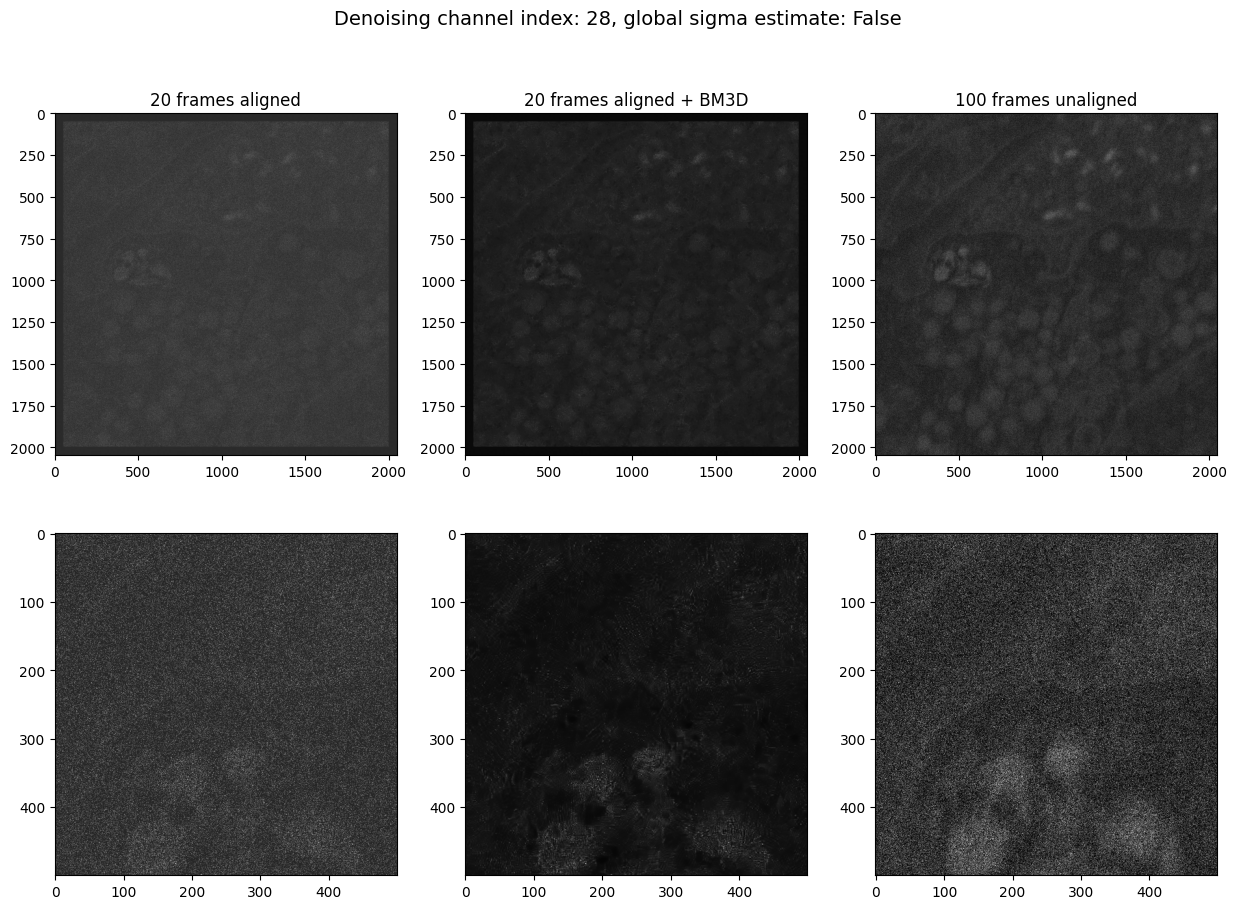

In [299]:
f, ax = plt.subplots(2,3,figsize=(15,10))
ax[0][0].imshow(channel_noisy, cmap='gray'); ax[0][0].set_title('20 frames aligned')
ax[0][1].imshow(channel_bm3d, cmap='gray'); ax[0][1].set_title('20 frames aligned + BM3D')
ax[0][2].imshow(channel_ref, cmap='gray'); ax[0][2].set_title('100 frames unaligned')
ax[1][0].imshow(channel_noisy[500:1000,250:750], cmap='gray')
ax[1][1].imshow(channel_bm3d[500:1000,250:750], cmap='gray')
ax[1][2].imshow(channel_ref[500:1000,250:750], cmap='gray')

plt.suptitle("Denoising channel index: %02d, global sigma estimate: %s" % (channel_idx, sigma_global), fontsize=14)
plt.show()

## BM3D with VST

#### Testing how to call matlab functions

In [300]:
import matlab.engine
eng = matlab.engine.start_matlab()
eng.addpath('../matlab/utils/', nargout=0)
y1,y2 = eng.toy_function(3, nargout=2)
print(y1, y2)
eng.quit()

6 9


#### Testing fit params

In [322]:
# select channel and remove padding
channel_idx = 3
channel_noisy = tile.EDX[:,:,channel_idx]
channel_ref = tile_ref.EDX[pad_remove:h-pad_remove, pad_remove:w-pad_remove,channel_idx]
channel_noisy = np.nan_to_num(channel_noisy, nan=0.0)
h,w,pad_remove = 2048,2048,50
channel_noisy = channel_noisy[pad_remove:h-pad_remove, pad_remove:w-pad_remove]
channel_noisy = np.ascontiguousarray(channel_noisy)

eng = matlab.engine.start_matlab()
matlab_path = eng.genpath('../matlab/')   # add path recursively
eng.addpath(matlab_path, nargout=0)


In [323]:
# estimate paramerters
params = eng.estimate_noise(channel_noisy, nargout=1)
print(params)
#eng.quit()

 !!! Clipping from above and clipping from below are mixed because randomness of noise is too high.  Forcing median_est=0, in order to have exact model for the clipping.  !!!
[[0.020536309646471018,0.08912693985207198]]


In [310]:
# alternative: global parameters, HSI-wise
pad_remove_x = 50
noisy_HSI_reshaped = tile.EDX[pad_remove_x:h-pad_remove_x, pad_remove_x:w-pad_remove_x,:].reshape(h-2*pad_remove_x,(w-2*pad_remove_x)*250)
print(noisy_HSI_reshaped.shape)
params = eng.estimate_noise(np.ascontiguousarray(noisy_HSI_reshaped), nargout=1)

(1948, 487000)


#### Run the whole protocol

In [324]:
a = params[0][0] if params[0][0]>=0 else 1e-30
b = params[0][1] if params[0][1]>=0 else 1e-30

print(a, b)
sigma = np.sqrt(b)

0.020536309646471018 0.08912693985207198


Text(0.5, 1.0, 'After VST')

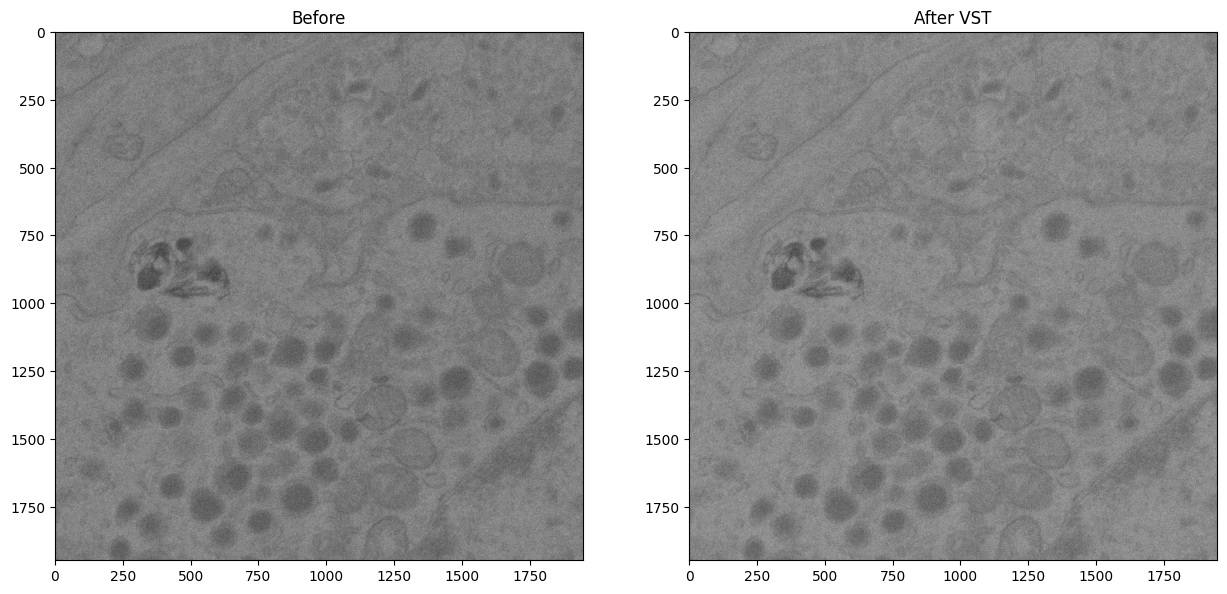

In [325]:
# forward vst
fz = eng.GenAnscombe_forward(channel_noisy, sigma.astype(channel_noisy.dtype), np.asanyarray(a,dtype=channel_noisy.dtype))
# display 
f, ax = plt.subplots(1,2,figsize=(15,10))
ax[0].imshow(channel_noisy,cmap='gray'); ax[0].set_title('Before')
ax[1].imshow(fz,cmap='gray'); ax[1].set_title('After VST')

In [326]:
# scale
sigma_den = 1
scale_range = 1
scale_shift = (1-scale_range)/2

fz, min, max = MinMax(fz, return_extra=True);   sigma_den = sigma_den/(max-min)
fz = fz*scale_range+scale_shift;   sigma_den = sigma_den*scale_range

In [327]:
# BM3D
channel_bm3d = bm3d(fz, sigma_psd=sigma_den, stage_arg=BM3DStages.ALL_STAGES)
channel_bm3d = (channel_bm3d-scale_shift)/scale_range
channel_bm3d = channel_bm3d*(max-min)+min
print('finished denoising')

finished denoising


In [328]:
# Inverse VST
channel_bm3d = eng.GenAnscombe_inverse_exact_unbiased(channel_bm3d, sigma, a);
channel_bm3d = np.asarray(channel_bm3d)

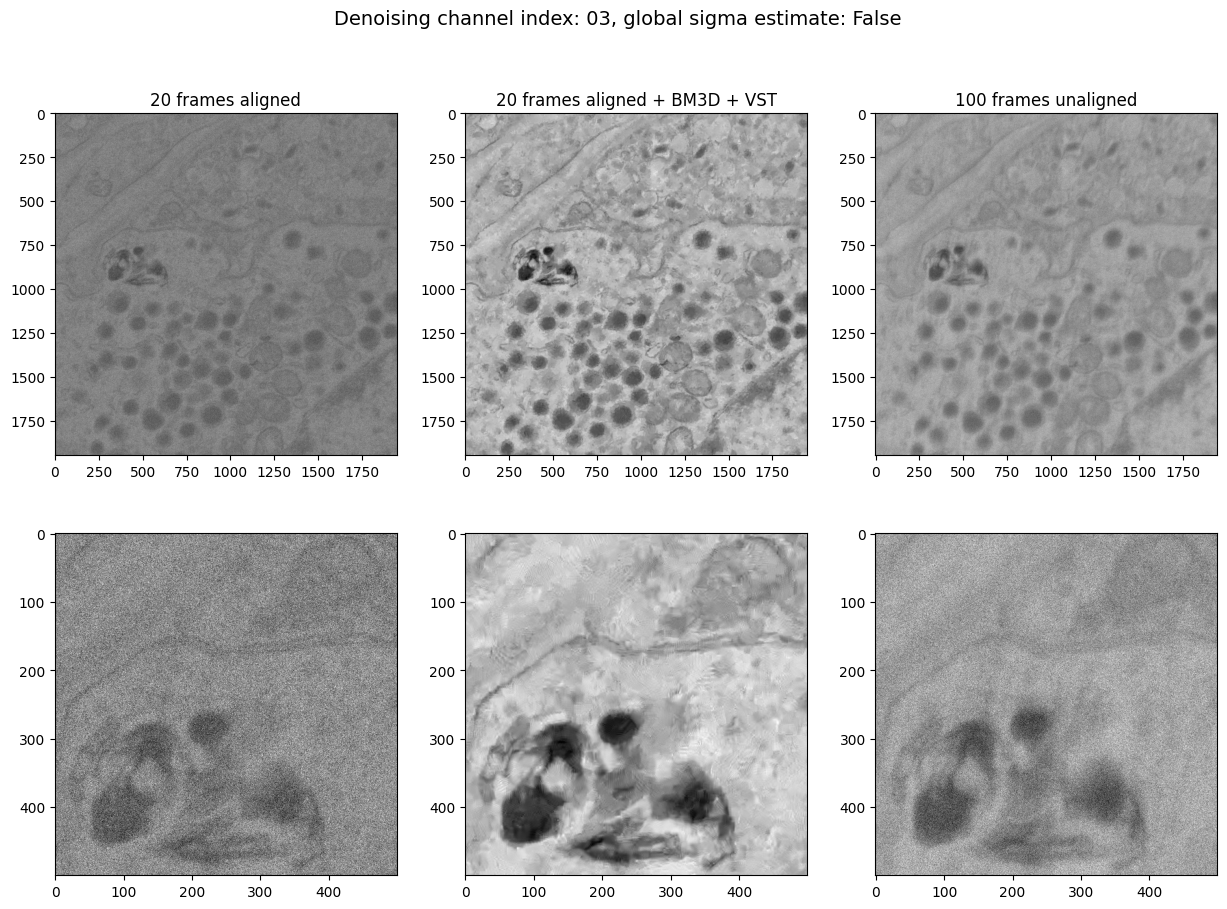

In [329]:
f, ax = plt.subplots(2,3,figsize=(15,10))
ax[0][0].imshow(channel_noisy, cmap='gray'); ax[0][0].set_title('20 frames aligned')
ax[0][1].imshow(channel_bm3d, cmap='gray'); ax[0][1].set_title('20 frames aligned + BM3D + VST')
ax[0][2].imshow(channel_ref, cmap='gray'); ax[0][2].set_title('100 frames unaligned')
ax[1][0].imshow(channel_noisy[500:1000,250:750], cmap='gray')
ax[1][1].imshow(channel_bm3d[500:1000,250:750], cmap='gray')
ax[1][2].imshow(channel_ref[500:1000,250:750], cmap='gray')

plt.suptitle("Denoising channel index: %02d, global sigma estimate: %s" % (channel_idx, sigma_global), fontsize=14)
plt.show()